In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torchvision
import matplotlib.pyplot as plt
import numpy as np
import os

In [3]:
#  Standard CNN model
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        # First Convolutional Block
        # Input: 1 channel (e.g., grayscale image from MNIST), Output: 32 channels
        # Applies 32 filters (kernels) of size 3x3 with padding=1 to maintain size (28x28 → 28x28)
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        # Max Pooling with 2x2 window: reduces each spatial dimension by half (28x28 → 14x14)
        self.pool1 = nn.MaxPool2d(kernel_size=2)

        # Second Convolutional Block
        # Input: 32 channels from previous layer, Output: 64 channels
        # Applies 64 filters of size 3x3, again with padding=1 to keep size (14x14 → 14x14)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        # Max Pooling: reduces size again by half (14x14 → 7x7)
        self.pool2 = nn.MaxPool2d(kernel_size=2)

        # Dropout layer with probability 0.25
        # Randomly disables 25% of neurons during training to prevent overfitting
        self.dropout = nn.Dropout(p=0.25)

        # Fully Connected Layer
        # Flattened input: 64 channels × 7 × 7 pixels = 3136 features
        # Output: 128 neurons
        self.fc1 = nn.Linear(in_features=64*7*7, out_features=128)
        # ReLU activation after fully connected layer
        self.relu3 = nn.ReLU()
        # Final output layer
        # Output: num_classes (e.g., 10 for digit classification)
        self.fc2 = nn.Linear(in_features=128, out_features=num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

In [4]:
# Improve CNN model with batch normalization and dropout
class ImprovedCNN(nn.Module):
    def __init__(self, num_classes=47):
        super(ImprovedCNN, self).__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 2
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 3
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.3)
        )

        self.classifier = nn.Sequential(
            nn.Linear(in_features=128 * 3 * 3, out_features=256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(in_features=256, out_features=num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

In [6]:
# Load the dataset
# Supports MNIST, FashionMNIST, KMNIST, and EMNIST
def load_data(dataset_name, batch_size=64):
    transform = transforms.ToTensor()

    if dataset_name == "MNIST":
        train_set = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
        test_set = datasets.MNIST(root='./data', train=False, transform=transform, download=True)
    elif dataset_name == "FashionMNIST":
        train_set = datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
        test_set = datasets.FashionMNIST(root='./data', train=False, transform=transform, download=True)
    elif dataset_name == "KMNIST":
        train_set = datasets.KMNIST(root='./data', train=True, transform=transform, download=True)
        test_set = datasets.KMNIST(root='./data', train=False, transform=transform, download=True)
    elif dataset_name == "EMNIST":
        train_set = datasets.EMNIST(root='./data', split='balanced', train=True, transform=transform, download=True)
        test_set = datasets.EMNIST(root='./data', split='balanced', train=False, transform=transform, download=True)
    else:
        raise ValueError("Unsupported dataset name.")

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader

In [7]:
# Evaluate the model
# Computes accuracy on test set
def evaluate_model(model, test_loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    return correct / total

In [8]:
def log_tensorboard(writer, model, train_loader, dataset_name):
    example_images, _ = next(iter(train_loader))
    writer.add_graph(model, example_images.to(next(model.parameters()).device))
    img_grid = torchvision.utils.make_grid(example_images[:16])
    writer.add_image(f"{dataset_name}_examples", img_grid)

In [9]:
# Train the model
# Saves the best model based on validation accuracy
# Logs training metrics to TensorBoard
def train_model(model, train_loader, test_loader, dataset_name="MNIST", epochs=5, lr=0.001, log_dir="runs"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    writer = SummaryWriter(log_dir=os.path.join(log_dir, dataset_name))
    log_tensorboard(writer, model, train_loader, dataset_name)

    checkpoint_dir = os.path.join("checkpoints", dataset_name)
    os.makedirs(checkpoint_dir, exist_ok=True)
    saved_model_accs = {}

    for epoch in range(epochs):
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0

        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct_train += (predicted == labels).sum().item()
            total_train += labels.size(0)

            step = epoch * len(train_loader) + i
            if i % 100 == 99:
                writer.add_scalar("Loss/Train", running_loss / 100, step)
                running_loss = 0.0
            if step % 300 == 0:
                for name, param in model.named_parameters():
                    writer.add_histogram(name, param, step)

        train_acc = correct_train / total_train
        val_acc = evaluate_model(model, test_loader, device)
        writer.add_scalars("Accuracy", {"Train": train_acc, "Validation": val_acc}, epoch)
        print(f"[{dataset_name}] Epoch {epoch+1}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")
            
        # Save the model every 5 epochs
        if (epoch + 1) % 5 == 0:
            filename = f"epoch_{epoch+1}.pth"
            save_path = os.path.join(checkpoint_dir, filename)
            torch.save(model.state_dict(), save_path)
            saved_model_accs[filename] = val_acc
            print(f"📦 Saved model to {filename} with accuracy {val_acc:.4f}")
    
    print(f"\n📊 Saved models & Accuracies: {saved_model_accs}")
    
    # Select the best model based on validation accuracy
    if saved_model_accs:
        best_filename = max(saved_model_accs, key=lambda k: saved_model_accs[k])
        best_acc = saved_model_accs[best_filename]
        best_model_path = os.path.join(checkpoint_dir, "best_model.pth")
        torch.save(torch.load(os.path.join(checkpoint_dir, best_filename)), best_model_path)
        print(f"\n✅ Saved best model to {best_filename} with accuracy {best_acc:.4f}")
    
        model.load_state_dict(torch.load(best_model_path))
        model = model.to(device)
        model.eval()

    writer.close()
    return model

In [10]:
# Visualize results
# Displays a grid of images with predicted and ground truth labels
# Highlights misclassified examples in red
def visualize_results(model, test_loader, class_names=None, num_images=10):
    model.eval()
    device = next(model.parameters()).device
    images, labels = next(iter(test_loader))
    images, labels = images.to(device), labels.to(device)

    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

    images = images.cpu().numpy()
    predicted = predicted.cpu().numpy()
    labels = labels.cpu().numpy()

    plt.figure(figsize=(num_images * 1.8, 2.5))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(images[i][0], cmap='gray')
        plt.axis('off')

        pred = predicted[i]
        gt = labels[i]
        
        if class_names:
            pred_text = class_names[pred]
            gt_text = class_names[gt]
        else:
            pred_text = str(pred)
            gt_text = str(gt)

        # Highlight misclassified examples
        title_color = 'green' if pred == gt else 'red'
        plt.title(f"P:{pred_text}\nGT:{gt_text}", fontsize=8, color=title_color)

    plt.suptitle("Test Predictions vs Ground Truth")
    plt.tight_layout()
    plt.show()

In [11]:
def get_class_names(dataset_name):
    if dataset_name == "FashionMNIST":
        return ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
    
    elif dataset_name == "EMNIST":
        return [
            '0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
            'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J',
            'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T',
            'U', 'V', 'W', 'X', 'Y', 'Z',
            'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't'
        ]
    
    return None  # For MNIST or others

In [12]:
def run_training_pipeline(dataset_name="MNIST", epochs=5, lr=0.001, model_type="SimpleCNN"):
    # Create the model
    num_classes = 47 if dataset_name == "EMNIST" else 10
    if model_type == "SimpleCNN":
        model = SimpleCNN(num_classes=num_classes)
    elif model_type == "ImprovedCNN":
        model = ImprovedCNN(num_classes=num_classes)
    elif model_type == "FurtherImprovedCNN":
        model = FurtherImprovedCNN(num_classes=num_classes)
    else:
        raise ValueError(f"Unsupported model_type: {model_type}")

    # Load dataset
    train_loader, test_loader = load_data(dataset_name)

    # Train model
    best_model = train_model(model, train_loader, test_loader, dataset_name, epochs=epochs, lr=lr)

    # Visualize results
    class_names = get_class_names(dataset_name)
    visualize_results(best_model, test_loader, class_names=class_names)

[MNIST] Epoch 1: Train Acc=0.9549, Val Acc=0.9885
[MNIST] Epoch 2: Train Acc=0.9847, Val Acc=0.9905
[MNIST] Epoch 3: Train Acc=0.9876, Val Acc=0.9918
[MNIST] Epoch 4: Train Acc=0.9897, Val Acc=0.9885
[MNIST] Epoch 5: Train Acc=0.9912, Val Acc=0.9901
📦 Saved model to epoch_5.pth with accuracy 0.9901
[MNIST] Epoch 6: Train Acc=0.9924, Val Acc=0.9907
[MNIST] Epoch 7: Train Acc=0.9937, Val Acc=0.9938
[MNIST] Epoch 8: Train Acc=0.9942, Val Acc=0.9936
[MNIST] Epoch 9: Train Acc=0.9950, Val Acc=0.9921
[MNIST] Epoch 10: Train Acc=0.9948, Val Acc=0.9928
📦 Saved model to epoch_10.pth with accuracy 0.9928
[MNIST] Epoch 11: Train Acc=0.9952, Val Acc=0.9929
[MNIST] Epoch 12: Train Acc=0.9959, Val Acc=0.9924
[MNIST] Epoch 13: Train Acc=0.9964, Val Acc=0.9923
[MNIST] Epoch 14: Train Acc=0.9971, Val Acc=0.9939
[MNIST] Epoch 15: Train Acc=0.9964, Val Acc=0.9924
📦 Saved model to epoch_15.pth with accuracy 0.9924
[MNIST] Epoch 16: Train Acc=0.9974, Val Acc=0.9945
[MNIST] Epoch 17: Train Acc=0.9975, Val A

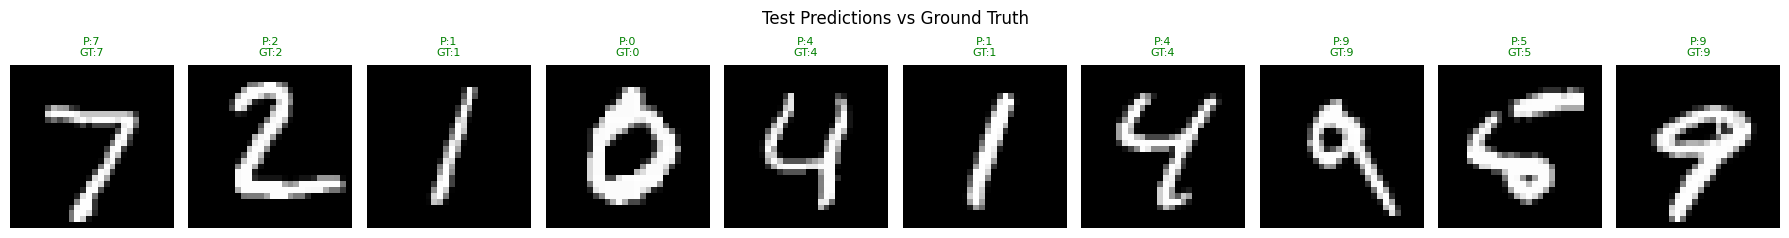

In [13]:
run_training_pipeline(dataset_name="MNIST", epochs=30, lr=0.0005, model_type="ImprovedCNN")

[FashionMNIST] Epoch 1: Train Acc=0.8406, Val Acc=0.8844
[FashionMNIST] Epoch 2: Train Acc=0.8935, Val Acc=0.8887
[FashionMNIST] Epoch 3: Train Acc=0.9076, Val Acc=0.9054
[FashionMNIST] Epoch 4: Train Acc=0.9165, Val Acc=0.9120
[FashionMNIST] Epoch 5: Train Acc=0.9236, Val Acc=0.9168
📦 Saved model to epoch_5.pth with accuracy 0.9168
[FashionMNIST] Epoch 6: Train Acc=0.9294, Val Acc=0.9153
[FashionMNIST] Epoch 7: Train Acc=0.9332, Val Acc=0.9204
[FashionMNIST] Epoch 8: Train Acc=0.9365, Val Acc=0.9250
[FashionMNIST] Epoch 9: Train Acc=0.9409, Val Acc=0.9263
[FashionMNIST] Epoch 10: Train Acc=0.9436, Val Acc=0.9258
📦 Saved model to epoch_10.pth with accuracy 0.9258
[FashionMNIST] Epoch 11: Train Acc=0.9495, Val Acc=0.9237
[FashionMNIST] Epoch 12: Train Acc=0.9512, Val Acc=0.9265
[FashionMNIST] Epoch 13: Train Acc=0.9554, Val Acc=0.9233
[FashionMNIST] Epoch 14: Train Acc=0.9560, Val Acc=0.9213
[FashionMNIST] Epoch 15: Train Acc=0.9588, Val Acc=0.9275
📦 Saved model to epoch_15.pth with acc

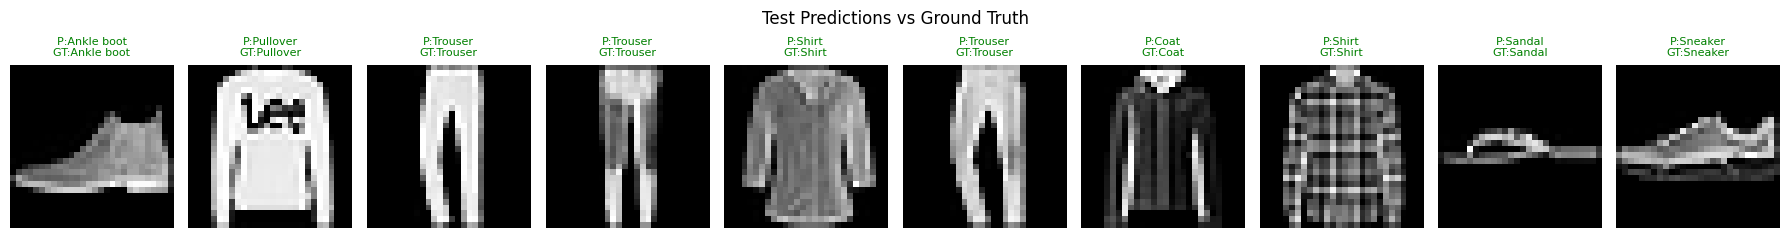

In [14]:
run_training_pipeline(dataset_name="FashionMNIST", epochs=30, lr=0.0005, model_type="ImprovedCNN")

[EMNIST] Epoch 1: Train Acc=0.7739, Val Acc=0.8536
[EMNIST] Epoch 2: Train Acc=0.8458, Val Acc=0.8737
[EMNIST] Epoch 3: Train Acc=0.8598, Val Acc=0.8735
[EMNIST] Epoch 4: Train Acc=0.8677, Val Acc=0.8827
[EMNIST] Epoch 5: Train Acc=0.8730, Val Acc=0.8868
📦 Saved model to epoch_5.pth with accuracy 0.8868
[EMNIST] Epoch 6: Train Acc=0.8779, Val Acc=0.8897
[EMNIST] Epoch 7: Train Acc=0.8821, Val Acc=0.8860
[EMNIST] Epoch 8: Train Acc=0.8843, Val Acc=0.8880
[EMNIST] Epoch 9: Train Acc=0.8885, Val Acc=0.8887
[EMNIST] Epoch 10: Train Acc=0.8887, Val Acc=0.8932
📦 Saved model to epoch_10.pth with accuracy 0.8932
[EMNIST] Epoch 11: Train Acc=0.8923, Val Acc=0.8873
[EMNIST] Epoch 12: Train Acc=0.8933, Val Acc=0.8933
[EMNIST] Epoch 13: Train Acc=0.8960, Val Acc=0.8947
[EMNIST] Epoch 14: Train Acc=0.8983, Val Acc=0.8924
[EMNIST] Epoch 15: Train Acc=0.9006, Val Acc=0.8899
📦 Saved model to epoch_15.pth with accuracy 0.8899
[EMNIST] Epoch 16: Train Acc=0.9005, Val Acc=0.8934
[EMNIST] Epoch 17: Train 

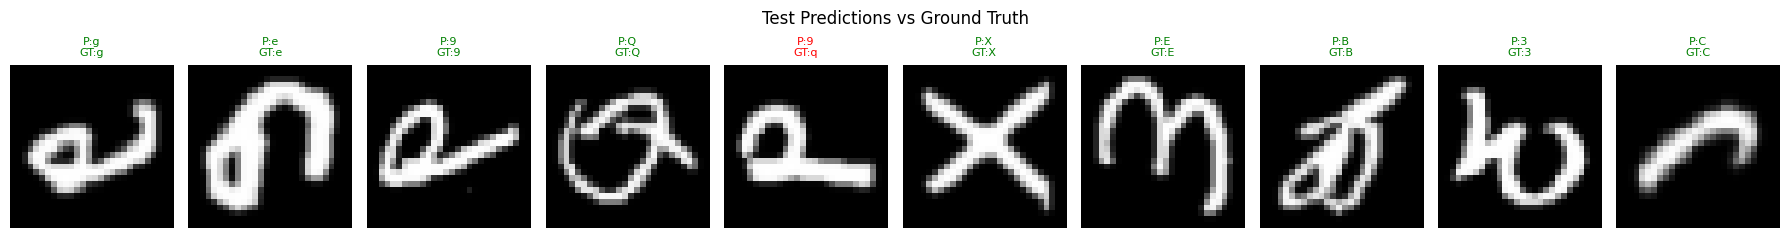

In [15]:
run_training_pipeline(dataset_name="EMNIST", epochs=30, lr=0.001, model_type="ImprovedCNN")

In [16]:
%load_ext tensorboard
%tensorboard --logdir=runs

Reusing TensorBoard on port 6006 (pid 166738), started 8 days, 10:19:05 ago. (Use '!kill 166738' to kill it.)